In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import shutil
import warnings 
warnings.filterwarnings('ignore')

In [2]:
#Unzipping the file into a csv file

shutil.unpack_archive('C:\\Users\\HP\\Desktop\\Machine Learning Projects\\India Flight Delay Prediction\\indian-flight-delay-datasets.zip', 'flight_delay.csv')

In [3]:
#Loading the dataset
df = pd.read_csv("C:\\Users\\HP\\Desktop\\Machine Learning Projects\\India Flight Delay Prediction\\flight_delay.csv\\india_flight_delay_model_input.csv")
df.head()

,Flight_Date,Airline,Flight_Number,Origin_Airport,Destination_Airport,Scheduled_Departure_Hour,Scheduled_Departure_Minute,Day_of_Week,Month,Is_Weekend,...,Humidity_pct,Wind_Speed_kmh,Visibility_km,Rainfall_mm,Cloud_Cover_pct,Origin_Congestion_Index,Previous_Flight_Delay_Minutes,Turnaround_Risk_Index,Departure_Delay,Delay_Target
0,2025-12-04,IndiGo,IN8723,BOM,DEL,13,57,3,12,0,...,46.1,4.3,9.8,5.2,0.0,63.5,0,23.9,43,1
1,2024-01-15,IndiGo,IN558,CCU,HYD,19,14,0,1,0,...,70.5,8.9,11.7,0.4,39.8,95.3,1,31.5,49,1
2,2023-11-06,Vistara,VI4949,HYD,DEL,8,50,0,11,0,...,53.7,7.8,9.6,4.3,16.6,100.0,1,41.5,73,1
3,2025-08-08,SpiceJet,SP3196,BLR,DIB,11,56,4,8,0,...,42.0,1.5,12.6,4.6,23.6,51.1,1,28.2,40,1
4,2023-09-09,IndiGo,IN8458,BLR,JGA,22,59,5,9,1,...,58.5,1.3,11.3,3.5,36.2,67.0,0,27.9,0,0


In [4]:
#Checking the data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 23 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Flight_Date                    150000 non-null  object 
 1   Airline                        150000 non-null  object 
 2   Flight_Number                  150000 non-null  object 
 3   Origin_Airport                 150000 non-null  object 
 4   Destination_Airport            150000 non-null  object 
 5   Scheduled_Departure_Hour       150000 non-null  int64  
 6   Scheduled_Departure_Minute     150000 non-null  int64  
 7   Day_of_Week                    150000 non-null  int64  
 8   Month                          150000 non-null  int64  
 9   Is_Weekend                     150000 non-null  int64  
 10  Peak_Hour                      150000 non-null  int64  
 11  Weather                        150000 non-null  object 
 12  Temperature_C                 

In [5]:
#converting the columns to lower case
df.columns = df.columns.str.lower()
df.columns

Index(['flight_date', 'airline', 'flight_number', 'origin_airport',
       'destination_airport', 'scheduled_departure_hour',
       'scheduled_departure_minute', 'day_of_week', 'month', 'is_weekend',
       'peak_hour', 'weather', 'temperature_c', 'humidity_pct',
       'wind_speed_kmh', 'visibility_km', 'rainfall_mm', 'cloud_cover_pct',
       'origin_congestion_index', 'previous_flight_delay_minutes',
       'turnaround_risk_index', 'departure_delay', 'delay_target'],
      dtype='object')

In [6]:
#converting the date columns to datetimeformat
df['flight_date'] = pd.to_datetime(df['flight_date'])




In [7]:
df.head()

,flight_date,airline,flight_number,origin_airport,destination_airport,scheduled_departure_hour,scheduled_departure_minute,day_of_week,month,is_weekend,...,humidity_pct,wind_speed_kmh,visibility_km,rainfall_mm,cloud_cover_pct,origin_congestion_index,previous_flight_delay_minutes,turnaround_risk_index,departure_delay,delay_target
0,2025-12-04,IndiGo,IN8723,BOM,DEL,13,57,3,12,0,...,46.1,4.3,9.8,5.2,0.0,63.5,0,23.9,43,1
1,2024-01-15,IndiGo,IN558,CCU,HYD,19,14,0,1,0,...,70.5,8.9,11.7,0.4,39.8,95.3,1,31.5,49,1
2,2023-11-06,Vistara,VI4949,HYD,DEL,8,50,0,11,0,...,53.7,7.8,9.6,4.3,16.6,100.0,1,41.5,73,1
3,2025-08-08,SpiceJet,SP3196,BLR,DIB,11,56,4,8,0,...,42.0,1.5,12.6,4.6,23.6,51.1,1,28.2,40,1
4,2023-09-09,IndiGo,IN8458,BLR,JGA,22,59,5,9,1,...,58.5,1.3,11.3,3.5,36.2,67.0,0,27.9,0,0


In [8]:
#Checking if the conversions are okay
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 23 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   flight_date                    150000 non-null  datetime64[ns]
 1   airline                        150000 non-null  object        
 2   flight_number                  150000 non-null  object        
 3   origin_airport                 150000 non-null  object        
 4   destination_airport            150000 non-null  object        
 5   scheduled_departure_hour       150000 non-null  int64         
 6   scheduled_departure_minute     150000 non-null  int64         
 7   day_of_week                    150000 non-null  int64         
 8   month                          150000 non-null  int64         
 9   is_weekend                     150000 non-null  int64         
 10  peak_hour                      150000 non-null  int64         
 11  

In [9]:
#checking data descriptions
df.describe()

,flight_date,scheduled_departure_hour,scheduled_departure_minute,day_of_week,month,is_weekend,peak_hour,temperature_c,humidity_pct,wind_speed_kmh,visibility_km,rainfall_mm,cloud_cover_pct,origin_congestion_index,previous_flight_delay_minutes,turnaround_risk_index,departure_delay,delay_target
count,150000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.00000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,2024-06-30 02:34:46.848000256,14.001260,29.533773,2.997107,6.512973,0.286820,0.47528,27.028051,56.332991,5.993765,10.891581,1.666205,25.013692,72.406212,6.170807,35.715187,42.664340,0.866167
min,2023-01-01 00:00:00,5.000000,0.000000,0.000000,1.000000,0.000000,0.00000,10.000000,20.000000,0.000000,5.100000,0.000000,0.000000,0.000000,0.000000,0.400000,0.000000,0.000000
25%,2023-10-01 00:00:00,9.000000,15.000000,1.000000,4.000000,0.000000,0.00000,22.900000,49.500000,2.900000,10.000000,0.000000,15.800000,60.900000,1.000000,29.900000,39.000000,1.000000
50%,2024-06-29 00:00:00,14.000000,30.000000,3.000000,7.000000,0.000000,0.00000,27.000000,56.300000,5.000000,10.900000,0.600000,24.800000,72.700000,4.000000,35.700000,47.000000,1.000000
75%,2025-03-31 00:00:00,19.000000,45.000000,5.000000,10.000000,1.000000,1.00000,31.100000,63.200000,8.100000,11.700000,2.500000,33.800000,88.800000,9.000000,41.500000,54.000000,1.000000
max,2025-12-30 00:00:00,23.000000,59.000000,6.000000,12.000000,1.000000,1.00000,45.000000,100.000000,35.000000,15.000000,30.400000,90.100000,100.000000,71.000000,88.200000,119.000000,1.000000
std,NaN,5.480291,17.322034,2.003977,3.445167,0.452278,0.49939,5.489234,10.161597,4.223185,1.271557,2.409718,13.020552,19.277706,6.483483,8.719541,19.016712,0.340474


In [10]:
#checking data shape
df.shape

(150000, 23)

In [11]:
#Checking the correlation of the numerical columns 

cols =[
       'scheduled_departure_hour',
       'scheduled_departure_minute', 'day_of_week', 'month', 'is_weekend',
       'peak_hour',  'temperature_c', 'humidity_pct',
       'wind_speed_kmh', 'visibility_km', 'rainfall_mm', 'cloud_cover_pct',
       'origin_congestion_index', 'previous_flight_delay_minutes',
       'turnaround_risk_index', 'departure_delay', 'delay_target']

corr = df[cols].corr()
corr

,scheduled_departure_hour,scheduled_departure_minute,day_of_week,month,is_weekend,peak_hour,temperature_c,humidity_pct,wind_speed_kmh,visibility_km,rainfall_mm,cloud_cover_pct,origin_congestion_index,previous_flight_delay_minutes,turnaround_risk_index,departure_delay,delay_target
scheduled_departure_hour,1.000000,0.001358,-0.000177,0.001768,-0.000439,0.060439,-0.001151,0.000487,0.000587,-0.004214,0.000594,-0.002244,0.036300,-0.002947,0.023158,0.023872,0.014564
scheduled_departure_minute,0.001358,1.000000,0.004781,-0.000875,0.003705,-0.001250,0.001627,0.001681,0.000756,0.003001,-0.000914,-0.001315,0.001487,-0.002207,-0.000633,0.003077,0.003367
day_of_week,-0.000177,0.004781,1.000000,0.004241,0.791906,-0.002503,-0.002154,0.000768,-0.002280,0.000596,0.003094,0.004202,0.130565,-0.001486,0.084090,0.074395,0.066168
month,0.001768,-0.000875,0.004241,1.000000,0.007480,-0.006668,0.152540,-0.000222,0.004100,0.003457,-0.001200,-0.000343,-0.003677,-0.002390,-0.005099,-0.000227,-0.000972
is_weekend,-0.000439,0.003705,0.791906,0.007480,1.000000,-0.005519,-0.002569,0.003442,-0.001136,-0.003400,0.002990,0.005143,0.164501,-0.003441,0.106537,0.094867,0.084462
peak_hour,0.060439,-0.001250,-0.002503,-0.006668,-0.005519,1.000000,-0.000051,-0.000928,0.002129,-0.000016,0.000690,-0.001219,0.624544,-0.000692,0.413611,0.397843,0.228089
temperature_c,-0.001151,0.001627,-0.002154,0.152540,-0.002569,-0.000051,1.000000,-0.001106,0.005283,-0.002414,-0.000146,-0.000067,0.000862,0.001285,0.003091,0.001716,0.000303
humidity_pct,0.000487,0.001681,0.000768,-0.000222,0.003442,-0.000928,-0.001106,1.000000,0.002244,-0.242371,0.180887,0.381494,-0.001772,-0.001448,-0.006812,0.017618,0.003118
wind_speed_kmh,0.000587,0.000756,-0.002280,0.004100,-0.001136,0.002129,0.005283,0.002244,1.000000,0.004217,-0.004744,0.003972,-0.000638,0.000398,-0.000122,0.002893,0.004636
visibility_km,-0.004214,0.003001,0.000596,0.003457,-0.003400,-0.000016,-0.002414,-0.242371,0.004217,1.000000,-0.260406,-0.141595,0.003224,-0.003023,0.001159,-0.027629,-0.008057


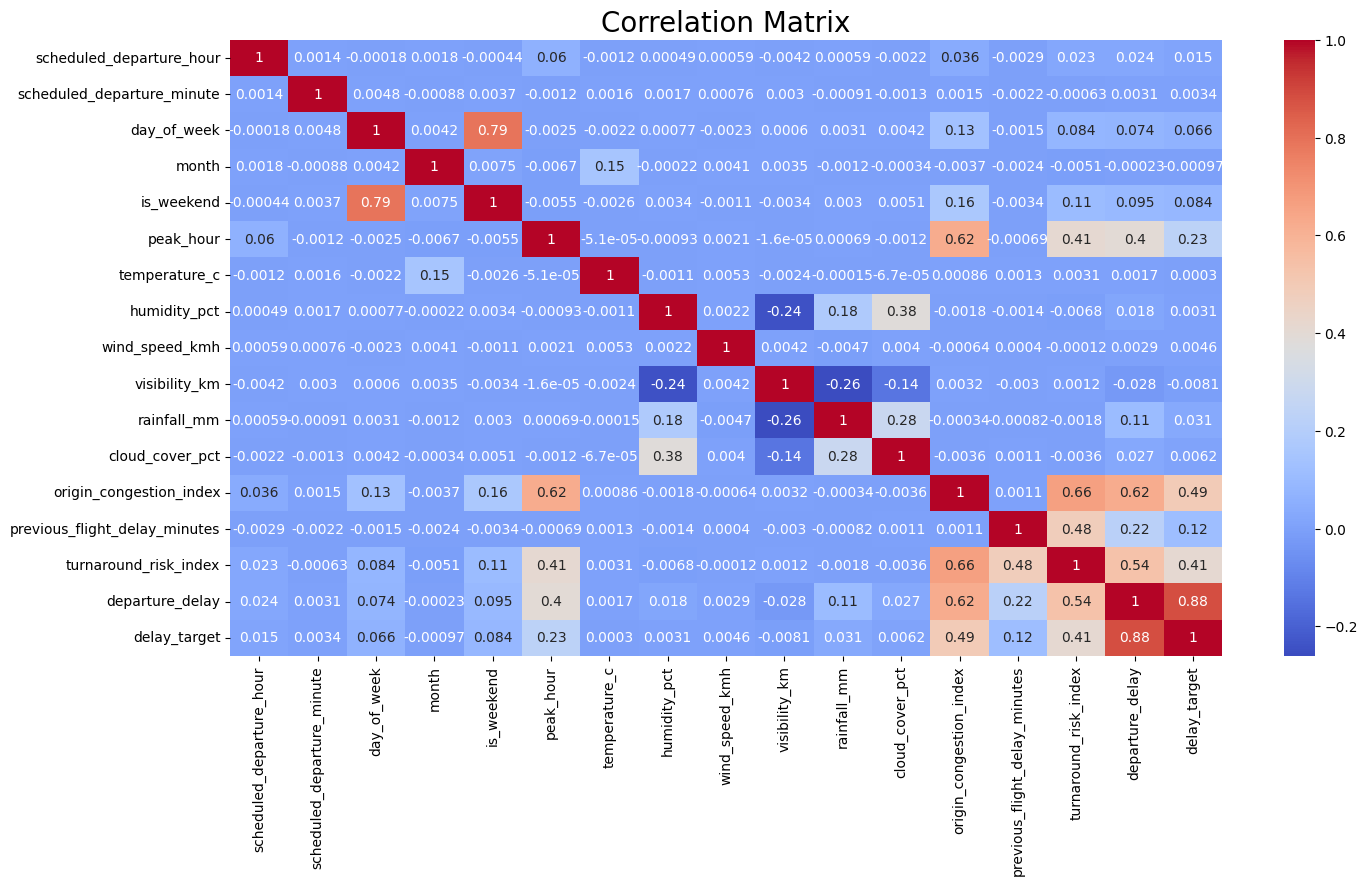

In [12]:
#heatmap of the corellation matrix
fig,ax = plt.subplots(figsize=(16,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')

ax.set_title('Correlation Matrix', fontsize=20)
plt.show()

In [13]:
df.head()

,flight_date,airline,flight_number,origin_airport,destination_airport,scheduled_departure_hour,scheduled_departure_minute,day_of_week,month,is_weekend,...,humidity_pct,wind_speed_kmh,visibility_km,rainfall_mm,cloud_cover_pct,origin_congestion_index,previous_flight_delay_minutes,turnaround_risk_index,departure_delay,delay_target
0,2025-12-04,IndiGo,IN8723,BOM,DEL,13,57,3,12,0,...,46.1,4.3,9.8,5.2,0.0,63.5,0,23.9,43,1
1,2024-01-15,IndiGo,IN558,CCU,HYD,19,14,0,1,0,...,70.5,8.9,11.7,0.4,39.8,95.3,1,31.5,49,1
2,2023-11-06,Vistara,VI4949,HYD,DEL,8,50,0,11,0,...,53.7,7.8,9.6,4.3,16.6,100.0,1,41.5,73,1
3,2025-08-08,SpiceJet,SP3196,BLR,DIB,11,56,4,8,0,...,42.0,1.5,12.6,4.6,23.6,51.1,1,28.2,40,1
4,2023-09-09,IndiGo,IN8458,BLR,JGA,22,59,5,9,1,...,58.5,1.3,11.3,3.5,36.2,67.0,0,27.9,0,0


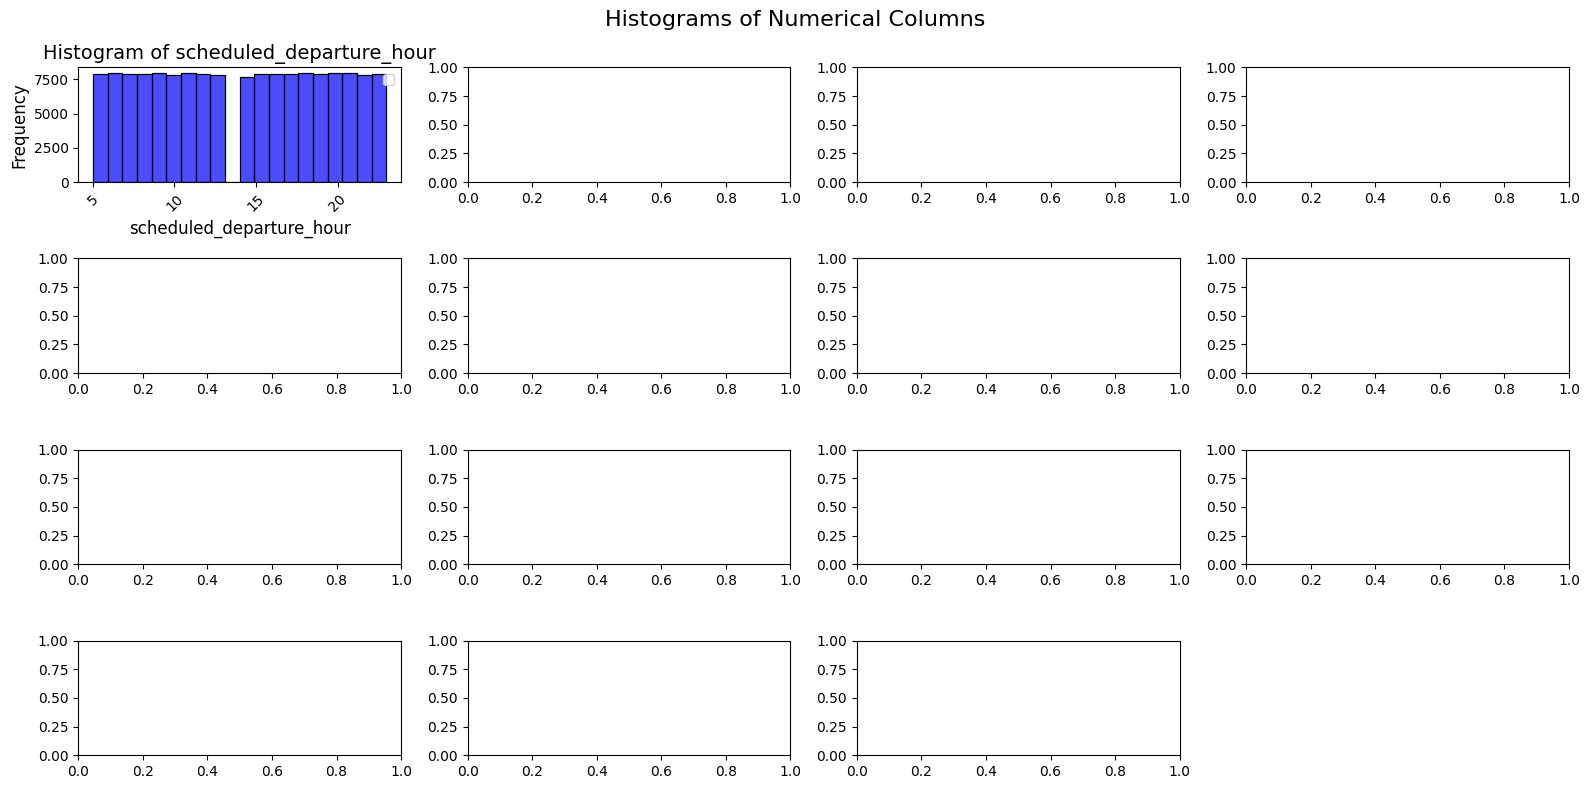

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [14]:
cols =[
       'scheduled_departure_hour',
       'scheduled_departure_minute', 
       'peak_hour',  'temperature_c', 'humidity_pct',
       'wind_speed_kmh', 'visibility_km', 'rainfall_mm', 'cloud_cover_pct',
       'origin_congestion_index', 'previous_flight_delay_minutes',
       'turnaround_risk_index', 'departure_delay']

fig, ax = plt.subplots(nrows=4, ncols=4, figsize=(16,8))

ax = ax.flatten()

for i, col in enumerate(cols):
    sns.histplot(data=df, x=col, bins=20, color='blue', alpha=0.7, ax=ax[i])
    ax[i].set_title(f'Histogram of {col}', fontsize=14)
    ax[i].set_xlabel(col, fontsize=12)
    ax[i].set_ylabel('Frequency', fontsize=12)

    ax[i].tick_params(axis='x', rotation=45)
    ax[i].legend()

    ax[-1].set_visible(False)

    plt.suptitle('Histograms of Numerical Columns', fontsize=16)
    plt.tight_layout()
    plt.show()

In [15]:
df.columns

Index(['flight_date', 'airline', 'flight_number', 'origin_airport',
       'destination_airport', 'scheduled_departure_hour',
       'scheduled_departure_minute', 'day_of_week', 'month', 'is_weekend',
       'peak_hour', 'weather', 'temperature_c', 'humidity_pct',
       'wind_speed_kmh', 'visibility_km', 'rainfall_mm', 'cloud_cover_pct',
       'origin_congestion_index', 'previous_flight_delay_minutes',
       'turnaround_risk_index', 'departure_delay', 'delay_target'],
      dtype='object')

In [16]:
df.groupby('airline')['previous_flight_delay_minutes'].aggregate(['mean','median'])

,mean,median
airline,,
Air India,6.178605,4.0
Air India Express,6.228438,4.0
Akasa Air,6.202899,4.0
Alliance Air,6.211496,4.0
Fly91,6.220305,4.0
IndiGo,6.146127,4.0
SpiceJet,6.210154,4.0
Star Air,6.037549,4.0
Vistara,6.168001,4.0


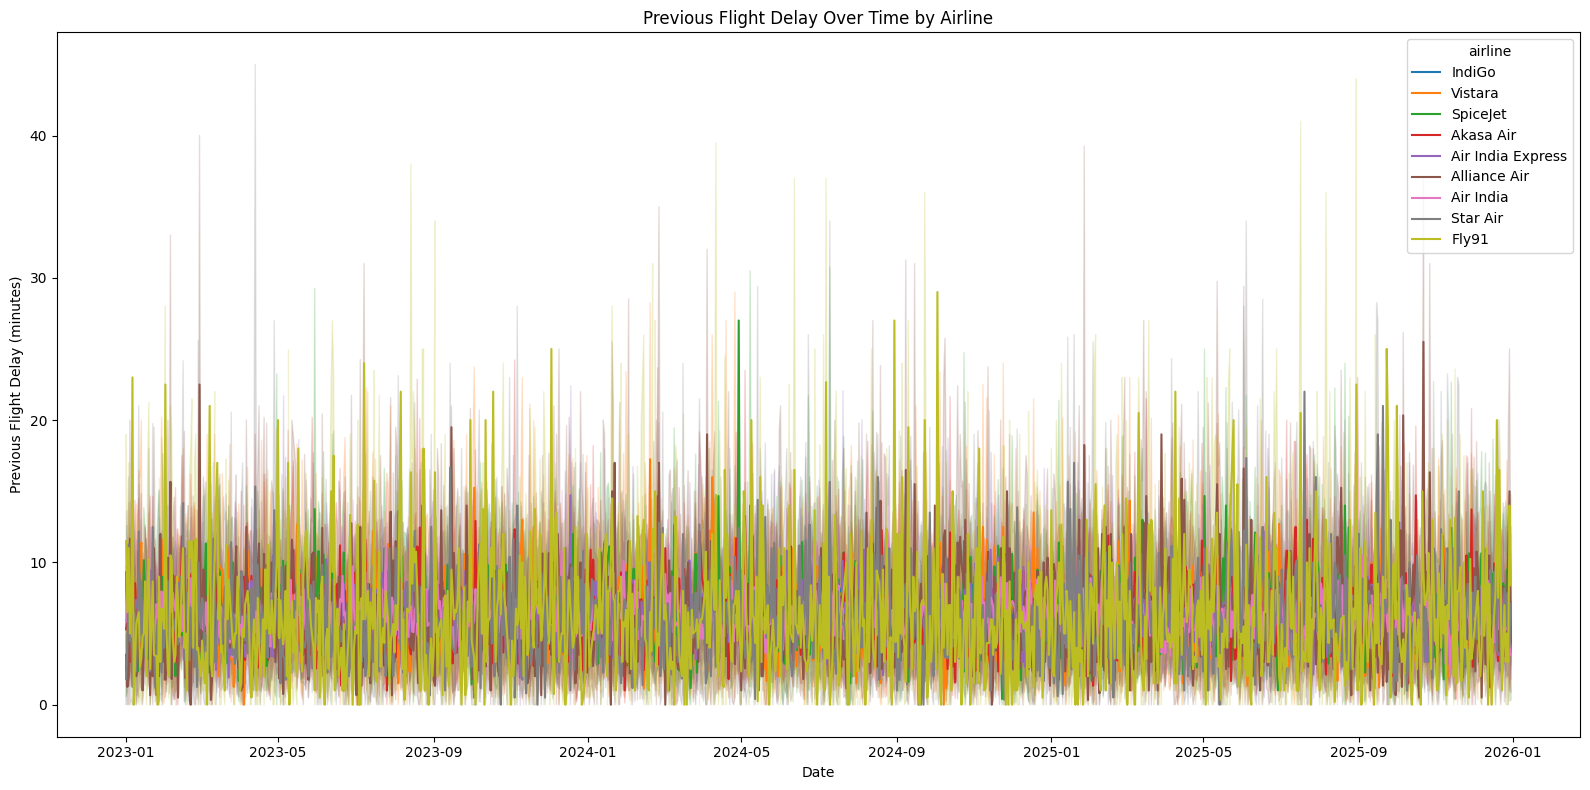

In [17]:
fig,ax = plt.subplots(figsize=(16,8))
sns.lineplot(data=df, 
             x='flight_date', 
             y='previous_flight_delay_minutes', 
             hue='airline')

ax.set_xlabel('Date')
ax.set_ylabel('Previous Flight Delay (minutes)')
ax.title.set_text('Previous Flight Delay Over Time by Airline')


plt.tight_layout()
plt.show()

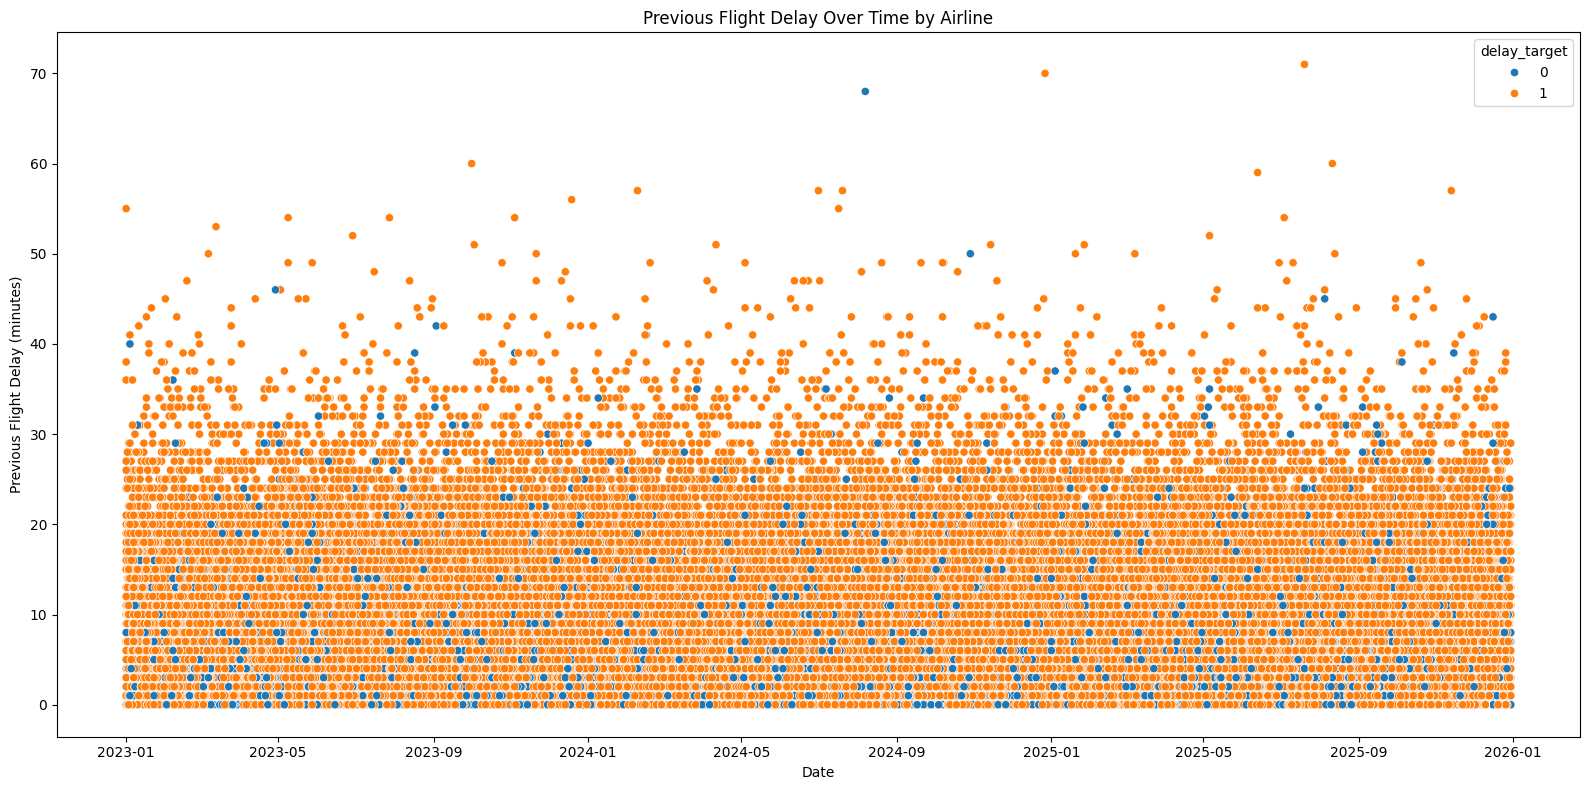

In [18]:
fig,ax = plt.subplots(figsize=(16,8))
sns.scatterplot(data=df, 
             x='flight_date', 
             y='previous_flight_delay_minutes', 
             hue='delay_target')

ax.set_xlabel('Date')
ax.set_ylabel('Previous Flight Delay (minutes)')
ax.title.set_text('Previous Flight Delay Over Time by Airline')


plt.tight_layout()
plt.show()

In [19]:
#Imporing machine learning libraries 
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer




In [20]:
df.head()

,flight_date,airline,flight_number,origin_airport,destination_airport,scheduled_departure_hour,scheduled_departure_minute,day_of_week,month,is_weekend,...,humidity_pct,wind_speed_kmh,visibility_km,rainfall_mm,cloud_cover_pct,origin_congestion_index,previous_flight_delay_minutes,turnaround_risk_index,departure_delay,delay_target
0,2025-12-04,IndiGo,IN8723,BOM,DEL,13,57,3,12,0,...,46.1,4.3,9.8,5.2,0.0,63.5,0,23.9,43,1
1,2024-01-15,IndiGo,IN558,CCU,HYD,19,14,0,1,0,...,70.5,8.9,11.7,0.4,39.8,95.3,1,31.5,49,1
2,2023-11-06,Vistara,VI4949,HYD,DEL,8,50,0,11,0,...,53.7,7.8,9.6,4.3,16.6,100.0,1,41.5,73,1
3,2025-08-08,SpiceJet,SP3196,BLR,DIB,11,56,4,8,0,...,42.0,1.5,12.6,4.6,23.6,51.1,1,28.2,40,1
4,2023-09-09,IndiGo,IN8458,BLR,JGA,22,59,5,9,1,...,58.5,1.3,11.3,3.5,36.2,67.0,0,27.9,0,0


In [21]:
#Splitting into dependent and Independent variable
X = df.drop(columns=['delay_target', 'flight_date'])
y = df['delay_target']

In [22]:
#splitting into training and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
#Splitting into categorical and numerical columns
categorical_cols = ['airline',
                    'weather',
                    'flight_number',
                    'origin_airport',
                    'destination_airport' ]

numerical_cols = df.drop(columns=categorical_cols + ['delay_target', 'flight_date']).columns.tolist()



In [25]:
preprocessing = ColumnTransformer(
    transformers=[("num", StandardScaler(), numerical_cols),
                   ("cat", OneHotEncoder(handle_unknown='ignore'), categorical_cols),
                   ])


In [26]:
models = {
    "LogisticRegression": LogisticRegression(), 
    "SVM": SVC(),   
    "DecisionTreeClassifier": DecisionTreeClassifier(),
    "RandomForestClassifier": RandomForestClassifier(),
    "GradientBoostingClassifier": GradientBoostingClassifier(),
    
}

In [27]:
def train_test_evaluate_models(models, preprocessing, X_train, y_train, X_test, y_test):
    results = {}    

    for name,model in models.items():


        pipeline = Pipeline([("preprocessing", preprocessing),
                                    ("model", model)])

        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)



        results[name]= {
                "classification_report" : classification_report(y_test,y_pred),
            "accuracy_score" :accuracy_score(y_test,y_pred),
                "confusion_matrix" :confusion_matrix(y_test,y_pred),
                "precision_score" :precision_score(y_test,y_pred),
                "recall_score":recall_score(y_test,y_pred)
            }
        print(f"{name}")
        print(results[name])

    return results




In [28]:
results = train_test_evaluate_models(models, 
                                     preprocessing, 
                                     X_train, 
                                     y_train, 
                                     X_test,
                                     y_test)
output = pd.DataFrame(results)


LogisticRegression
{'classification_report': '              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00      4006\n           1       1.00      1.00      1.00     25994\n\n    accuracy                           1.00     30000\n   macro avg       1.00      1.00      1.00     30000\nweighted avg       1.00      1.00      1.00     30000\n', 'accuracy_score': 1.0, 'confusion_matrix': array([[ 4006,     0],
       [    0, 25994]]), 'precision_score': 1.0, 'recall_score': 1.0}
SVM
{'classification_report': '              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00      4006\n           1       1.00      1.00      1.00     25994\n\n    accuracy                           1.00     30000\n   macro avg       1.00      1.00      1.00     30000\nweighted avg       1.00      1.00      1.00     30000\n', 'accuracy_score': 1.0, 'confusion_matrix': array([[ 4006,     0],
       [    0, 25994]]), 'precision_score': 1.0